In [1]:
###binary logistic regression problem as there are only two possible outcomes (i.e. if person buys insurance or he/she doesn't).

In [2]:
# Import required libraries
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
%matplotlib inline

In [3]:
#read the file
df =  pd.read_csv('insurance_data.csv')

In [4]:
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


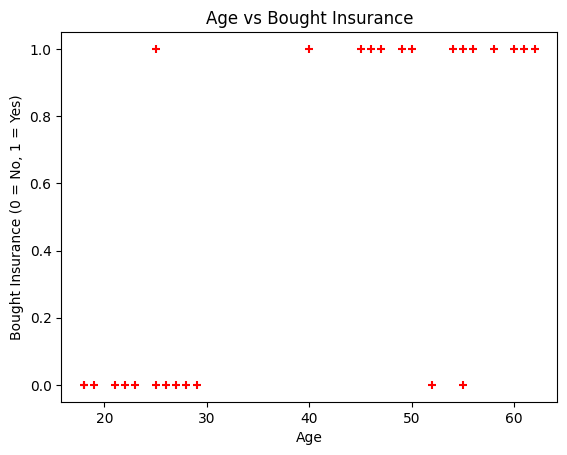

In [5]:
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
plt.xlabel("Age")
plt.ylabel("Bought Insurance (0 = No, 1 = Yes)")
plt.title("Age vs Bought Insurance")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train, y_test = train_test_split(df[['age']], df.bought_insurance , train_size=0.8)

In [8]:
X_test

,age
15,55
16,25
7,60
4,46
9,61
12,27


In [9]:
X_train

,age
19,18
5,56
13,29
18,19
24,50
11,28
25,54
6,55
14,49
17,58


In [10]:
y_train

19    0
5     1
13    0
18    0
24    1
11    0
25    1
6     0
14    1
17    1
2     1
20    0
26    0
23    1
0     0
22    1
1     0
10    0
8     1
3     0
21    0
Name: bought_insurance, dtype: int64

In [11]:
y_test

15    1
16    1
7     1
4     1
9     1
12    0
Name: bought_insurance, dtype: int64

In [12]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [13]:
model.fit(X_train ,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
X_test

,age
15,55
16,25
7,60
4,46
9,61
12,27


In [15]:
y_predicted = model.predict(X_test)

In [16]:
model.predict_proba(X_test)

array([[0.12420951, 0.87579049],
       [0.93897904, 0.06102096],
       [0.06098066, 0.93901934],
       [0.36652884, 0.63347116],
       [0.052625  , 0.947375  ],
       [0.91842422, 0.08157578]])

In [48]:
#shows accuracy of the model
model.score(X_test,y_test)

0.8333333333333334

In [18]:
y_predicted

array([1, 0, 1, 1, 1, 0])

In [19]:
X_test

,age
15,55
16,25
7,60
4,46
9,61
12,27


*model.coef_ indicates value of m in y=m*x + b equation*

In [20]:
model.coef_

array([[0.15622443]])

In [21]:
model.intercept_

array([-6.63918657])

In [22]:
model.predict([[35]])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [23]:
model.predict([[45]])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [24]:
model.predict([[20]])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [25]:
model.predict([[50]])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [26]:
#now we do manual calculation to check whether its working properly
import math
def sigmoid(x) :
    return 1/ (1+ math.exp(-x))

In [27]:
def prediction_function(age):
    z = 0.042 * age - 1.53 #0.042 is coeff and 1.53 is intercept
    y = sigmoid(z)
    return y

In [28]:
age = 35
prediction_function(age)

0.4850044983805899

In [29]:
#0,.485 is less than 0.5 so that means the person will not buy the insurance

In [30]:
age = 49
prediction_function(age)

0.6290165230447227

In [31]:
#here the value is 0.629 that is greater than 0.5 which means that the person will buy the insurance

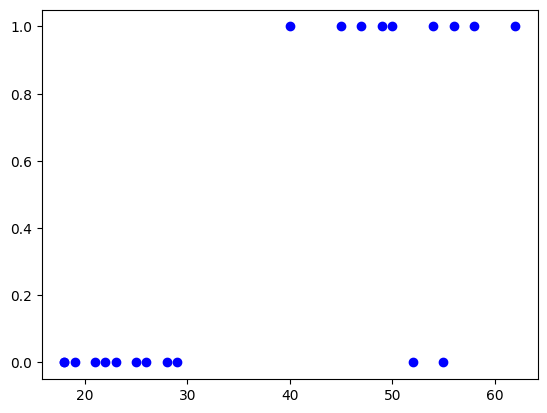

In [32]:
#plot actual data points
plt.scatter(X_train ,y_train, color='blue', label= 'Actual data')

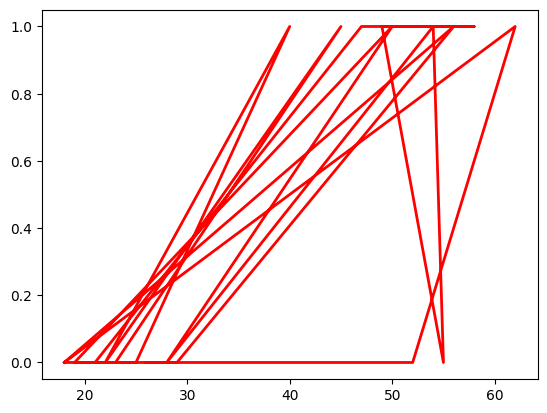

In [33]:
#plot sigmoid curve
plt.plot(X_train,y_train, color= 'red', linewidth= 2, label= 'Logistic regression(sigmoid)')

C:\Users\HP\AppData\Local\Temp\ipykernel_2596\2840968761.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


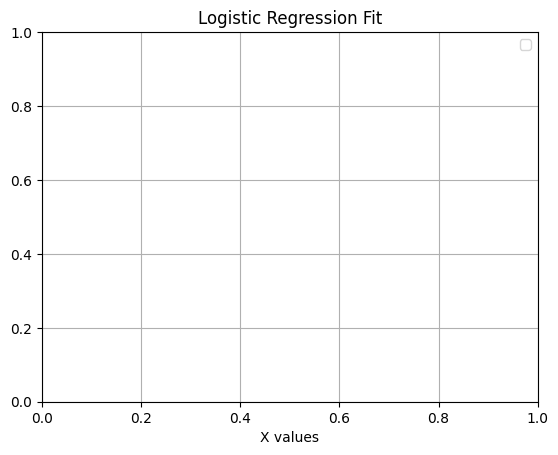

In [34]:
#add lables and titles
plt.xlabel('X values')
plt.title('Logistic Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
#generate prediction for sigmoid curve

In [39]:
X_curve = np.linspace(df.age.min(), df.age.max(),200).reshape(-1,1)
y_prob = model.predict_proba(X_curve)[:,1]  #probability of class 1 (buying insurance)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


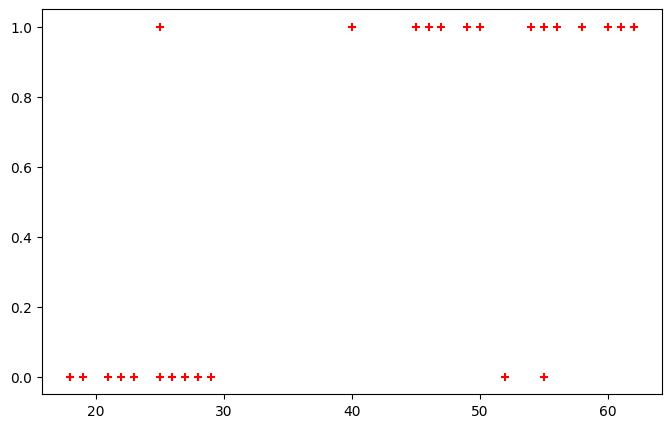

In [42]:
#plot logistic regression sigmoid curve
plt.figure(figsize=(8,5))
plt.scatter(df.age, df.bought_insurance, color='red', marker='+', label='Actual Data')

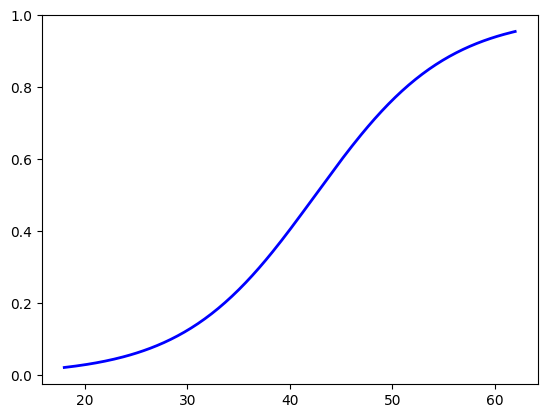

In [43]:
plt.plot(X_curve, y_prob,color= 'blue', linewidth= 2, label= 'Logistix regression(sigmoid curve)')

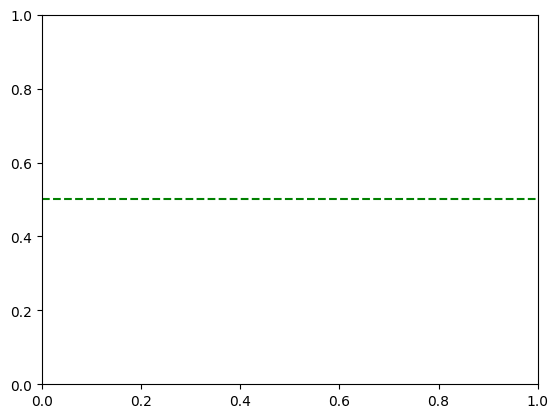

In [44]:
plt.axhline(0.5, color= 'green', linestyle= '--', label='Decision Boundary (0.5)')

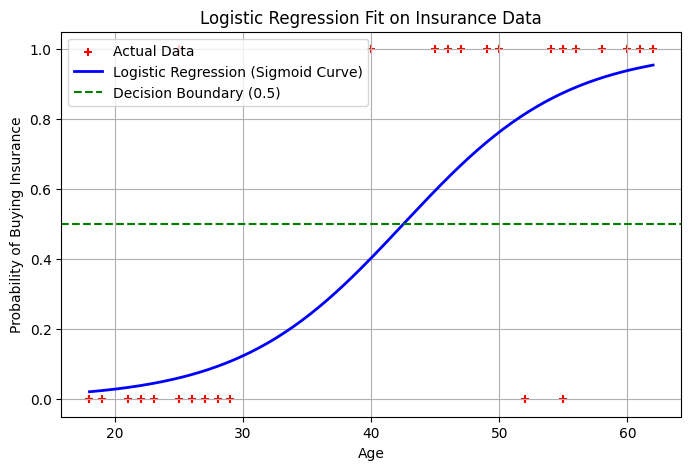

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(df.age, df.bought_insurance, color='red', marker='+', label='Actual Data')
plt.plot(X_curve, y_prob, color='blue', linewidth=2, label='Logistic Regression (Sigmoid Curve)')
plt.axhline(0.5, color='green', linestyle='--', label='Decision Boundary (0.5)')
plt.xlabel("Age")
plt.ylabel("Probability of Buying Insurance")
plt.title("Logistic Regression Fit on Insurance Data")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# Display decision boundary (Age where probability = 0.5)
decision_boundary = -model.intercept_[0] / model.coef_[0][0]
print(f"Decision Boundary (Age where probability=0.5): {decision_boundary:.2f}")

Decision Boundary (Age where probability=0.5): 42.50
